CoinGecko API Collection: Do Larger Cryptocurrencies Experience Lower Price Volatility?

Laura Melo

ECO 590

Spring 2026

This notebook shows my updated work for assignments 1 (Data Collection) & 2 (Graphing)

Motivation: In today’s financial system cryptocurrency markets play an important role and their prices change frequently. Market capitalization shows the size of the cryptocurrency, while price volatility shows how much its price has changed. This project will research how these two are related to better understand the differences in risk and stability across cryptocurrencies. 

Sources Used: 
1. "C:\Users\laura\OneDrive\Documents\ECO590\Data_Analysis_Python_R\New Data City Access Granted\Lecture 4.ipynb" (Lecture 4 Notes)
2. "C:\Users\laura\OneDrive\Documents\ECO590\Data_Analysis_Python_R\Lets get this data started  Pandas\Lecture 6.ipynb" (Lecture 6 Notes)
3. https://www.youtube.com/watch?v=JVQNywo4AbU (YouTube video)
4. https://www.youtube.com/watch?v=hpc5jyVpUpw (YouTube Video)
5. https://stackoverflow.com/questions/61977076/how-to-fetch-data-from-api-using-python
6. Lecture 8
7. Lecture 9
8. https://www.youtube.com/watch?v=NcffDnVBPHA (Creating Graphs in Python)
9. https://www.youtube.com/watch?v=ewXzgCow94g (Creating Scatter Plots in Python)
10. https://htmlcolorcodes.com/ (HTML Color Codes)
11. https://machinelearningplus.com/plots/python-scatter-plot/ (Scatter Plot)

Part 1 - Getting the Data 

In [33]:
import requests #imports the requests into python 
import pandas as pd #imports pandas into python 

1. Creating the dataset from the API 

In [34]:
url = "https://api.coingecko.com/api/v3/coins/markets?vs_currency=usd" #link of CoinGecko API (where I get the crypto data)

#settings for the API request 
params = {
    "vs_currency": "usd", #get prices in US dollars
    "order": "market_cap_desc", #sort coins by biggest market cap first
    "per_page": 50, #gets the top 50 cryptocurrencies
    "page": 1, #first page of results 
    "price_change_percentage": "24h" #include 24-hour price change % 
}
response = requests.get(url, params=params) #sends request to the API and gets the data
data = response.json() #converts the response into JSON format 
df = pd.DataFrame(data) #turns the data into a pandas dataframe 

2. Keeping only the needed columns for the project 

In [35]:
df = df[['name', 'current_price', 'market_cap', 'total_volume', 'price_change_percentage_24h']] #keeps only the columns that is needed for this project 

3. Calculates the new variable (Price Volatility) 

Variable Explanation: This new variable creates price volatility by using the absolute value of the 24-hour price change. Which shows how much the price changes in one day, and if it went up or down. 


In [36]:
df['price_volatility'] = df['price_change_percentage_24h'].abs() #creates the price volatility variable using absolute value of 24h price change 

4. Calculates the new variable (Volume to Market Cap Ratio) - Added new a variable based on the feedback 

Variable Explanation: This new variable shows trading volume as a percentage of market cap, showing how much of a crypto’s total market value is being traded in a day (used for regression model 3) 

In [38]:
df['volume_to_market_cap_ratio'] = df['total_volume'] / df['market_cap'] #creates a ratio that compares the trading volume to the market cap 

5. Making sure the data set was collected correctly 

In [39]:
df.info() #checks for column names and data types 
df.isnull().sum() #checks if any of the columns have missing values
df.describe() #shows the summary statistics to check if the numbers in the data set make sense

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   name                         50 non-null     object 
 1   current_price                50 non-null     float64
 2   market_cap                   50 non-null     int64  
 3   total_volume                 50 non-null     float64
 4   price_change_percentage_24h  49 non-null     float64
 5   price_volatility             49 non-null     float64
 6   volume_to_market_cap_ratio   50 non-null     float64
dtypes: float64(5), int64(1), object(1)
memory usage: 2.9+ KB


,current_price,market_cap,total_volume,price_change_percentage_24h,price_volatility,volume_to_market_cap_ratio
count,50.000000,5.000000e+01,5.000000e+01,49.000000,49.000000,50.000000
mean,1902.403662,5.300686e+10,2.720397e+09,-1.458346,1.776917,0.058869
std,11404.222493,2.308401e+11,9.575861e+09,2.151787,1.891575,0.107490
min,0.000006,1.782551e+09,0.000000e+00,-8.759040,0.000000,0.000000
25%,0.751911,2.836276e+09,4.241837e+07,-2.847590,0.170770,0.010723
50%,1.125000,4.406622e+09,1.784811e+08,-0.992440,1.204090,0.024975
75%,53.552500,9.942281e+09,4.550037e+08,-0.001950,2.928340,0.067239
max,80641.000000,1.616036e+12,5.801486e+10,5.652510,8.759040,0.693397


7. Saving the data set into a csv file 

In [22]:
df.to_csv("crypto_data.csv", index=False)

Regression Explanation: I am going to run a regression where price volatility is the dependent variable, and trading volume and market capitalization are the independent variables. This would help me analyze how market activity and size can affect cryptocurrency price fluctuations.

Part 2 - Graphs 

In [40]:
#Imports the csv into python 
import pandas as pd 
df = pd.read_csv(r"C:\Users\laura\crypto_data.csv") 

Graph 1 - Top 10 Cryptocurrencies by Market Cap (Bar Chart)

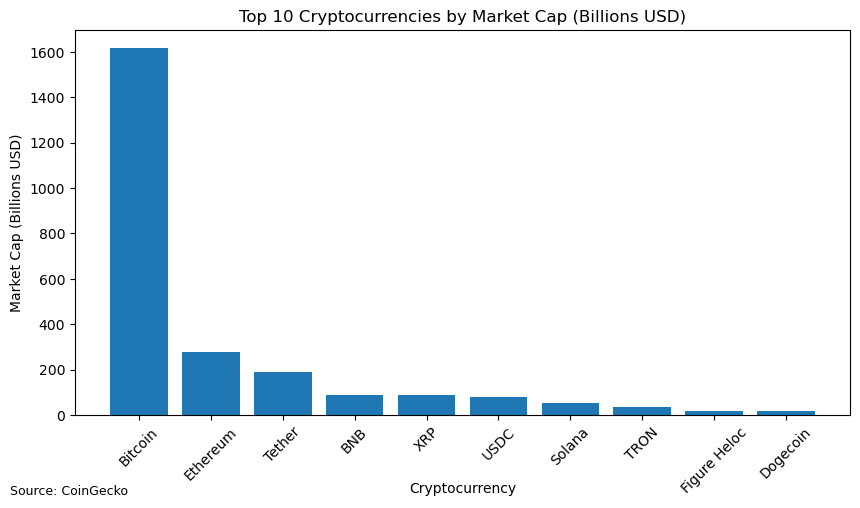

In [24]:
top_marketcap = df.sort_values(by='market_cap', ascending=False).head(10) #sorts the top 10 cryptos by market cap 

import matplotlib.pyplot as plt #imports the plotting library

plt.figure(figsize=(10,5)) #sets the figure size 
top_marketcap['market_cap_billions'] = top_marketcap['market_cap'] / 1000000000 #divides the market cap into billions 
plt.bar(top_marketcap['name'], top_marketcap['market_cap_billions']) #creates the bar chart 
plt.title("Top 10 Cryptocurrencies by Market Cap (Billions USD)") #creats the bar chart title 
plt.xlabel("Cryptocurrency", labelpad=-10) #sets the x-axis title 
plt.ylabel("Market Cap (Billions USD)") #sets the y-axis title 
plt.xticks(rotation=45) #rotates names so they fit 
plt.figtext(0.06, -0.05, "Source: CoinGecko", ha="left", fontsize=9) #adds the source 

plt.show() #prints the graph 

This bar chart shows the top 10 cryptocurrencies by their market cap, with Bitcoin being the highest. This shows that a few cryptocurrencies dominate the market.

Graph 2 - Top 10 Cryptocurrencies by Trading Volume (Bar Chart) 

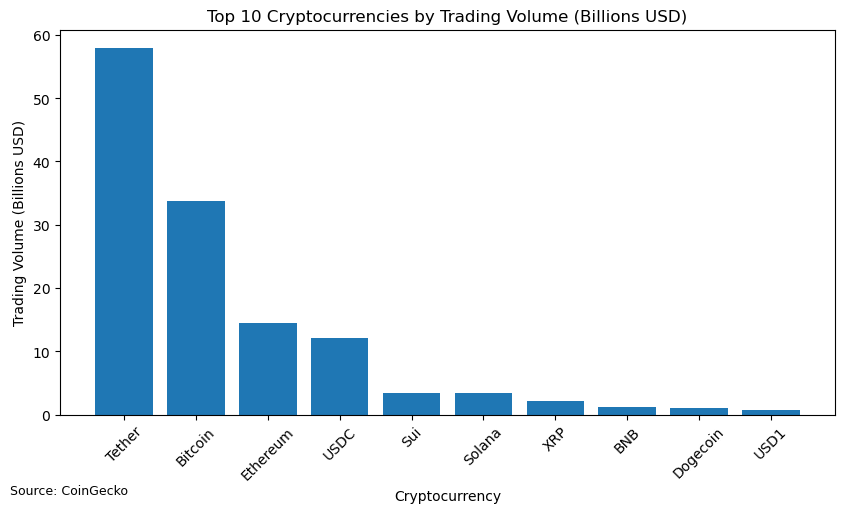

In [25]:
top_volume = df.sort_values(by='total_volume', ascending=False).head(10) #sorts trading volume by top 10
top_volume['volume_billions'] = top_volume['total_volume'] / 1000000000 #divides numbers into billions 

plt.figure(figsize=(10,5)) #sets the size 
plt.bar(top_volume['name'], top_volume['volume_billions']) #creates bar chart 
plt.title("Top 10 Cryptocurrencies by Trading Volume (Billions USD)") #sets title of bar chart 
plt.xlabel("Cryptocurrency", labelpad= 5) #sets the x-axis label
plt.ylabel("Trading Volume (Billions USD)") #set y-axis label
plt.xticks(rotation=45) #rotates names 
plt.figtext(0.075, -0.05, "Source: CoinGecko", ha="left", fontsize=9) #adds source to graph 

plt.show() #prints the graph 

This bar chart shows the top 10 cryptocurrencies by their trading volume, with Tether and Bitcoin having the highest trading activity. This information shows that these coins are traded the most compared to others. 


Shows Graphs 1 and 2 Side by Side 

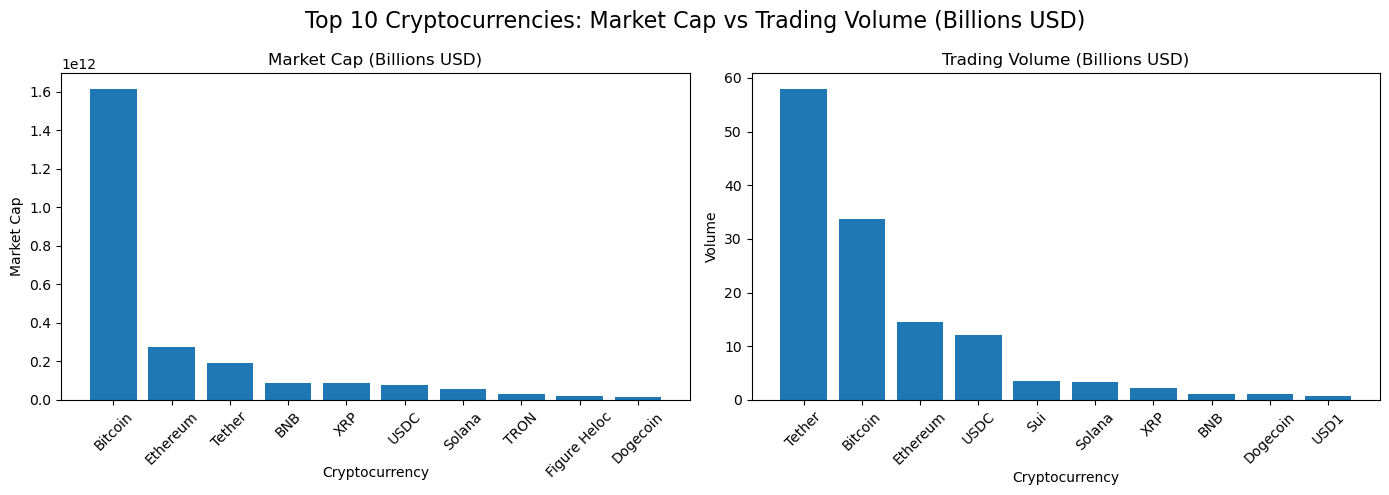

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14,5)) #sets 1 row, 2 columns 
fig.suptitle("Top 10 Cryptocurrencies: Market Cap vs Trading Volume (Billions USD)", fontsize=16) #adds the main title 

#Graph 1 - Market Cap
axes[0].bar(top_marketcap['name'], top_marketcap['market_cap']) #creates bar chart
axes[0].set_title("Market Cap (Billions USD)") #adds the title 
axes[0].set_xlabel("Cryptocurrency", labelpad=-10) #x-axis label 
axes[0].set_ylabel("Market Cap") #y-axis label 
axes[0].tick_params(axis='x', rotation=45) #rotates the labels 

#Graph 2 - Trading Volume 
axes[1].bar(top_volume['name'], top_volume['volume_billions']) #creates bar chart
axes[1].set_title("Trading Volume (Billions USD)") #adds the title 
axes[1].set_xlabel("Cryptocurrency", labelpad= 2.5) #x-axis label 
axes[1].set_ylabel("Volume") #y-axis label 
axes[1].tick_params(axis='x', rotation=45) #rotates the labels 
plt.tight_layout() #fixes spacing

plt.show() #prints both graphs side by side 

These graphs side-by-side show the top 10 cryptocurrencies by market cap and trading volume. While some coins like Bitcoin have both high market cap and high trading volume, others like Tether have very high trading volume but lower market cap, which shows that size does not always match trading activity. This relates to how different cryptocurrencies behave in the market.


Graph 3 - Market Cap vs. Price Volatility (Scatter Plot)

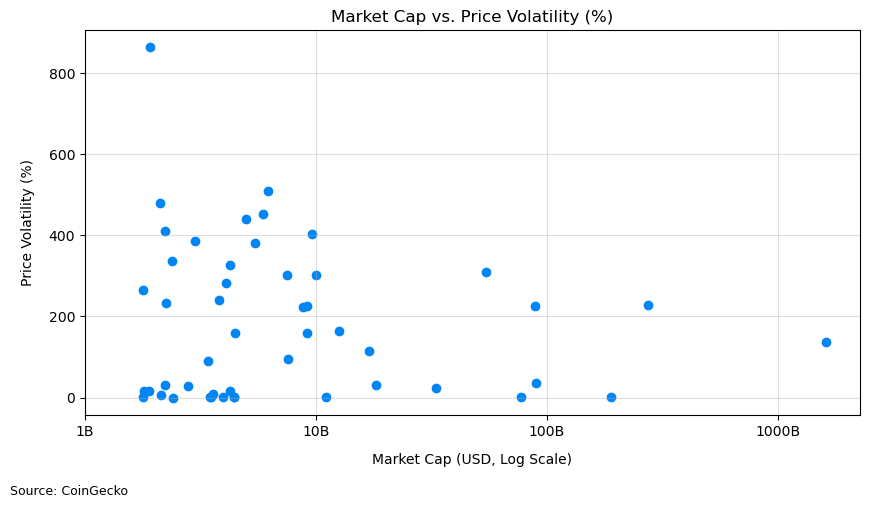

In [27]:
plt.figure(figsize=(10,5)) #sets the graph size 
plt.scatter(df['market_cap'], df['price_volatility'] * 100,color='#0085F5') #creates the scatter plot 

plt.xscale('log') #used log scale to show large differences in market caps 
plt.xticks([1e9, 1e10, 1e11, 1e12], ['1B', '10B', '100B', '1000B']) #customizes x-axis scale to show values in billions 
plt.minorticks_off() #removes excess ticks (used AI to help remove tiny ticks appearing in graph) 
plt.title("Market Cap vs. Price Volatility (%)") #adds title 
plt.xlabel("Market Cap (USD, Log Scale)", labelpad = 10) #x-axis label 
plt.ylabel("Price Volatility (%)", labelpad=10) #y-axis label 
plt.grid(alpha=0.4) #adds light grid to make it easier to read 
plt.figtext(0.05, -0.05, "Source: CoinGecko", ha="left", fontsize=9) #shows source 

plt.show() #prints the graph 

This graph shows that smaller cryptocurrencies experience more price volatility, while larger cryptocurrencies tend to have more stable price movements. This suggests that larger market capitalization may be associated with lower risk. 


Graph 4 (Extra) - Distribution of Volatility Across all Coins (Histogram)

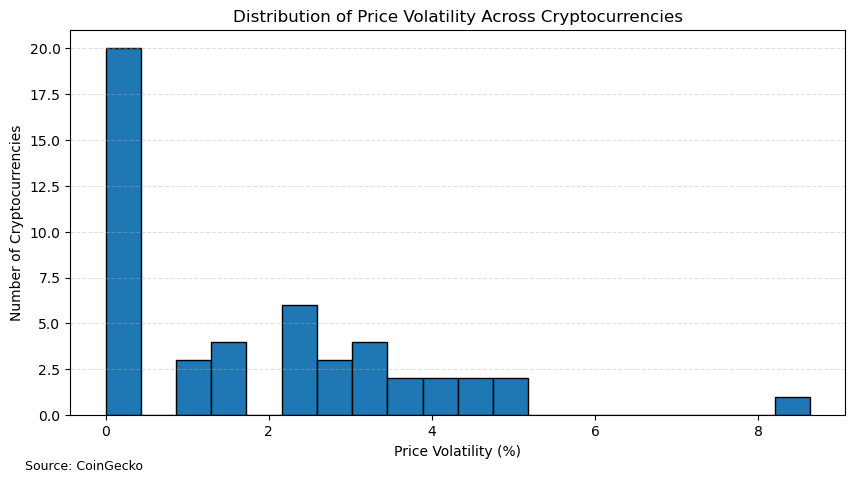

In [43]:
#Graph 4 (Extra) - Distribution of Volatility Across all Coins (Histogram)
plt.figure(figsize=(10,5)) #sets the figure size 

plt.hist(df['price_volatility'],bins=20,edgecolor='black',linewidth=1) #creates the histogram

plt.title("Distribution of Price Volatility Across Cryptocurrencies") #adds the graph title 
plt.xlabel("Price Volatility (%)") #x-axis label 
plt.ylabel("Number of Cryptocurrencies") #y-axis label 
plt.grid(axis='y', linestyle='--', alpha=0.4) #adds light grid lines 
plt.figtext(0.08, 0, "Source: CoinGecko", ha="left", fontsize=9) #adds source to the graph 

plt.show() #prints the graph 

This histogram shows that most cryptocurrencies in the data set have low price volatility, showing most coins clustered near the lower end of the graph. There are only a few cryptocurrencies that have very high volatility, which shows that extreme daily price changes are less frequent but they are still important in the crypto market. 
